IMPORT

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

BASE_DIR = Path("..")

CLEANED_DATA_PATH = BASE_DIR / "data" / "processed" / "cleaned_online_retail.csv"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
TABLES_DIR = BASE_DIR / "outputs" / "tables"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


LOAD CLEANED DATA

In [2]:
df = pd.read_csv(CLEANED_DATA_PATH)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Cleaned dataset loaded.")
print("Shape:", df.shape)

df.head()

Cleaned dataset loaded.
Shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


DEFINE REFERENCE DATE

In [3]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Last transaction date:", df["InvoiceDate"].max())
print("Reference date used for Recency:", reference_date)

Last transaction date: 2011-12-09 12:50:00
Reference date used for Recency: 2011-12-10 12:50:00


CREATE RFM FEATURE

In [4]:
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print("RFM dataset created.")
print("Shape:", rfm.shape)

rfm.head()

RFM dataset created.
Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


RFM SUMMARY

In [5]:
rfm_summary = rfm[["Recency", "Frequency", "Monetary"]].describe().T

rfm_summary.to_csv(TABLES_DIR / "rfm_summary_statistics.csv")

rfm_summary

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


CHECK RFM DATA QUALITY

In [6]:
print("Missing values in RFM:")
print(rfm.isnull().sum())

print("\nDuplicate CustomerID count:")
print(rfm["CustomerID"].duplicated().sum())

print("\nNumber of customers in RFM dataset:")
print(rfm["CustomerID"].nunique())

Missing values in RFM:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

Duplicate CustomerID count:
0

Number of customers in RFM dataset:
4338


RECENCY DISTRIBUTION

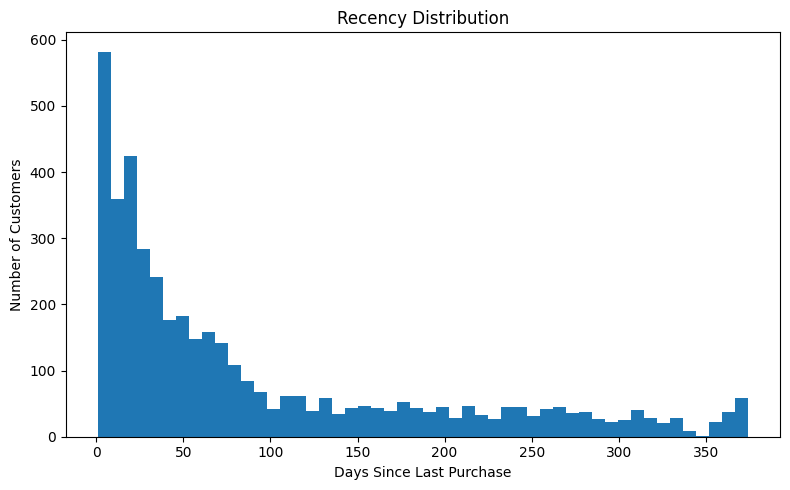

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(rfm["Recency"], bins=50)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rfm_recency_distribution.png", dpi=300)
plt.show()

FREQUENCY DISTRIBUTION

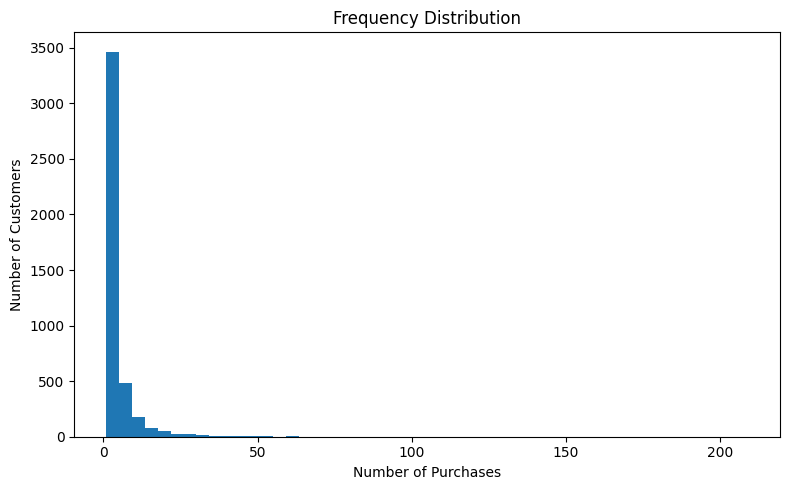

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(rfm["Frequency"], bins=50)
plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rfm_frequency_distribution.png", dpi=300)
plt.show()

MONETARY DISTRIBUTION

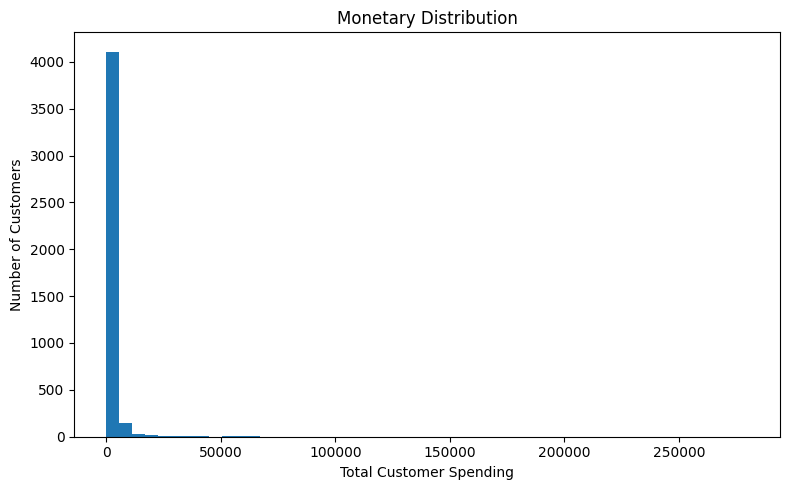

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(rfm["Monetary"], bins=50)
plt.title("Monetary Distribution")
plt.xlabel("Total Customer Spending")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rfm_monetary_distribution.png", dpi=300)
plt.show()

LOG TRANSFORMED MONETARY DISTRIBUTION

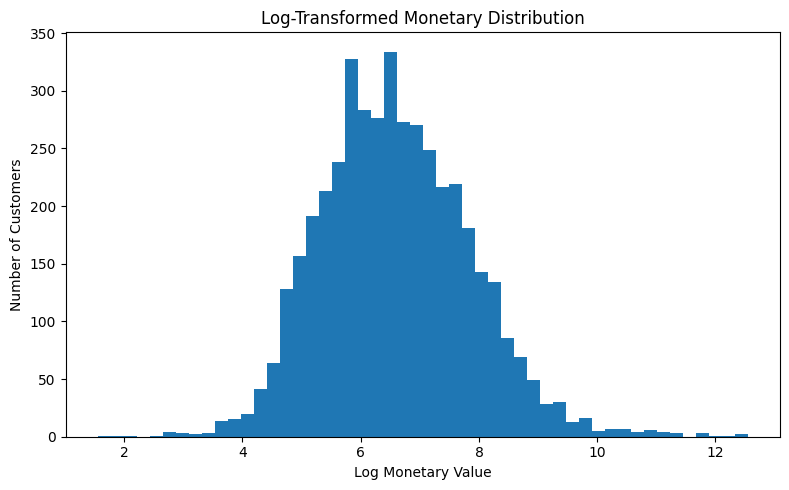

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(rfm["Monetary"]), bins=50)
plt.title("Log-Transformed Monetary Distribution")
plt.xlabel("Log Monetary Value")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rfm_log_monetary_distribution.png", dpi=300)
plt.show()

RFM CORELATION MATRIX

In [11]:
rfm_corr = rfm[["Recency", "Frequency", "Monetary"]].corr()

rfm_corr.to_csv(TABLES_DIR / "rfm_correlation_matrix.csv")

rfm_corr

,Recency,Frequency,Monetary
Recency,1.000000,-0.260578,-0.121831
Frequency,-0.260578,1.000000,0.552780
Monetary,-0.121831,0.552780,1.000000


RFM CORELATION HEATMAP

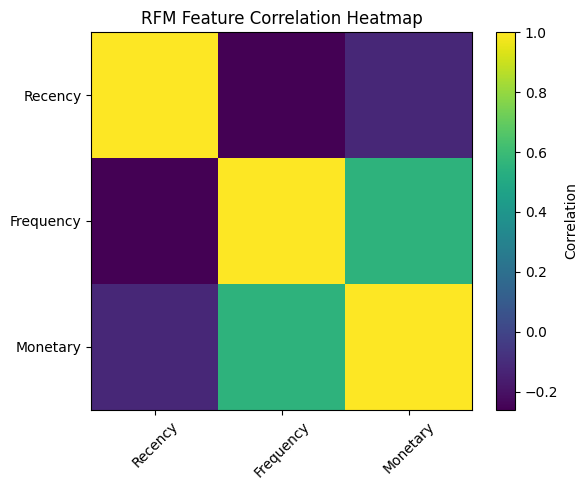

In [12]:
plt.figure(figsize=(6, 5))
plt.imshow(rfm_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(rfm_corr.columns)), rfm_corr.columns, rotation=45)
plt.yticks(range(len(rfm_corr.index)), rfm_corr.index)
plt.title("RFM Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rfm_correlation_heatmap.png", dpi=300)
plt.show()

SAVE RFM FEATURES

In [13]:
rfm.to_csv(PROCESSED_DIR / "rfm_features.csv", index=False)

print("RFM features saved successfully.")
print("File path:", PROCESSED_DIR / "rfm_features.csv")

RFM features saved successfully.
File path: ..\data\processed\rfm_features.csv


EXPLANATION 

In [ ]:
print("RFM FEATURE ENGINEERING SUMMARY")
print("--------------------------------")
print(f"Total customers segmented: {rfm['CustomerID'].nunique():,}")
print("RFM features created:")
print("- Recency: days since last purchase")
print("- Frequency: number of unique invoices")
print("- Monetary: total customer spending")
print("These features form the baseline traditional segmentation model.")

RFM FEATURE ENGINEERING SUMMARY
--------------------------------
Total customers segmented: 4,338
RFM features created:
- Recency: days since last purchase
- Frequency: number of unique invoices
- Monetary: total customer spending
These features form the baseline traditional segmentation model.


: 